## Import needed libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

### Loading dataset

In [9]:
df = pd.read_csv('telco.csv')
df.head(2)

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.0,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.8,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [4]:
df.shape

(7043, 50)

In [5]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


## Handling Missing Value

In [6]:
df.isna().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [7]:
df['Offer'].nunique()

5

In [8]:
df.loc[df['Offer'].isna(), 'Offer'] = 'No'

In [9]:
df['Offer'].head()

0         No
1    Offer E
2    Offer D
3    Offer C
4    Offer C
Name: Offer, dtype: object

In [10]:
df['Internet Type'].unique()

array(['DSL', 'Fiber Optic', 'Cable', nan], dtype=object)

In [11]:
df['Internet Type'].value_counts(normalize=True)

Internet Type
Fiber Optic    0.550118
DSL            0.299438
Cable          0.150444
Name: proportion, dtype: float64

In [12]:
df['Internet Type'].fillna(df['Internet Type'].mode()[0], inplace=True)

C:\Users\Ctrl-Halim\AppData\Local\Temp\ipykernel_20656\1996115549.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Internet Type'].fillna(df['Internet Type'].mode()[0], inplace=True)


In [13]:
df.drop(['Churn Category','Churn Reason'], axis=1, inplace=True)

## Univariate Analysis

In [14]:
df.head(1)

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,39.65,0.0,20,0.0,59.65,3,Churned,Yes,91,5433


In [15]:
# Distribution of Gender
px.pie(df, names='Gender', title='Distribution of Gender')



- From this distribution we find that `Male` are more churn from `Female` but in a very small percentage

Text(0.5, 1.0, 'Distribution of Age')

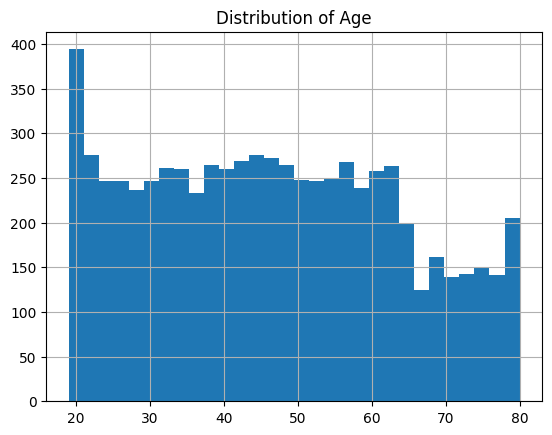

In [16]:
# EDA Distribution Age 

df['Age'].hist(bins=30)
plt.title('Distribution of Age')

In [17]:
# Distribution of Senior Citizen
df['Under 30'].value_counts(normalize=True).reset_index()

,Under 30,proportion
0,No,0.801079
1,Yes,0.198921


In [18]:
# Distribution of Senior Citizen
df['Senior Citizen'].value_counts(normalize=True).reset_index()

,Senior Citizen,proportion
0,No,0.837853
1,Yes,0.162147


- We can see from this distribution that the age of the customers is between `30` and `60`

Text(0.5, 1.0, 'Distribution of Married')

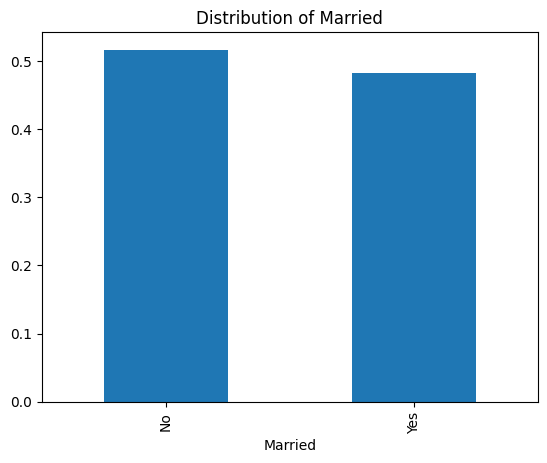

In [19]:
# Distribution of Married
df['Married'].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribution of Married')

Text(0.5, 1.0, 'Distribution of Dependents')

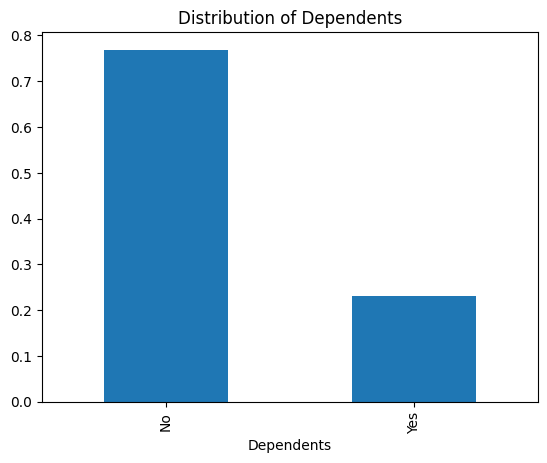

In [20]:
df['Dependents'].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribution of Dependents')

In [21]:
# Distribution of Dependents
df['Number of Dependents'].value_counts(normalize=True).reset_index()

,Number of Dependents,proportion
0,0,0.768990
1,1,0.078518
2,2,0.075394
3,3,0.073406
4,5,0.001420
5,4,0.001278
6,6,0.000426
7,7,0.000284
8,8,0.000142
9,9,0.000142


Text(0.5, 1.0, 'Distribution of Number of Dependents')

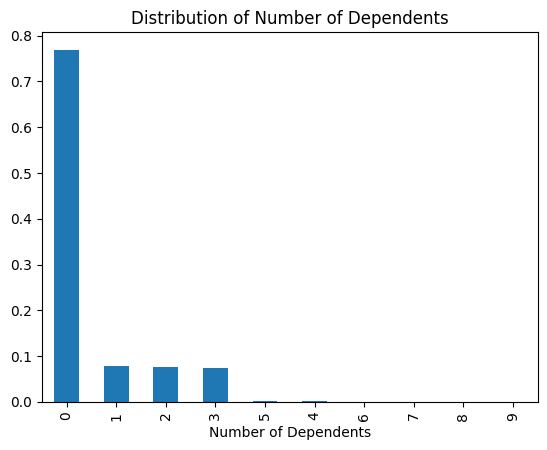

In [22]:
df['Number of Dependents'].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribution of Number of Dependents')

In [23]:
df['City'].nunique()

1106

Text(0.5, 1.0, 'Distribution of City')

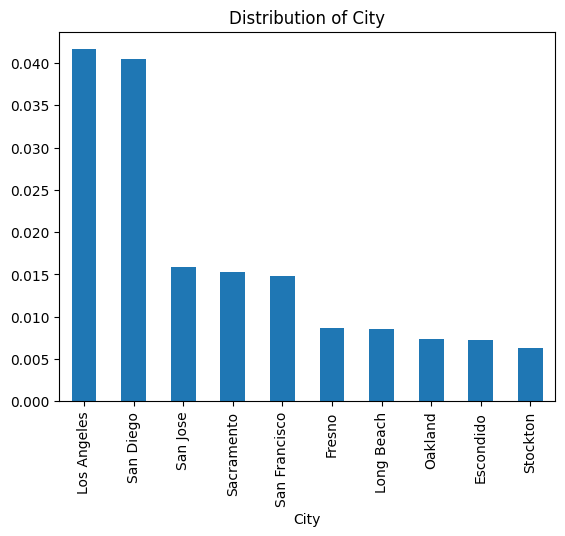

In [24]:
# Distribution of City
df['City'].value_counts(normalize=True).head(10).plot(kind='bar')
plt.title('Distribution of City')

Text(0.5, 1.0, 'Distribution of Population')

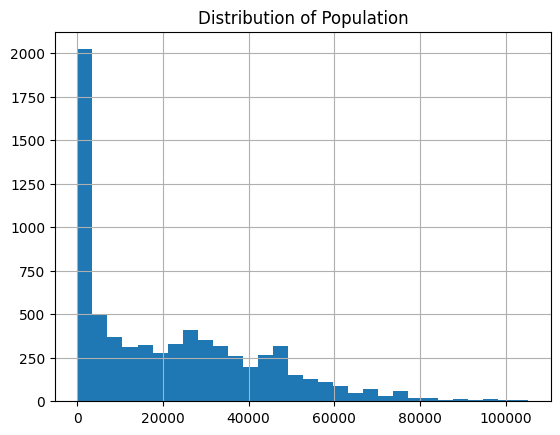

In [25]:
# Distribution of Population
df['Population'].hist(bins=30)
plt.title('Distribution of Population')

In [26]:
# Distribution of Referred a Friend
df['Referred a Friend'].value_counts(normalize=True).reset_index()

,Referred a Friend,proportion
0,No,0.542524
1,Yes,0.457476


In [27]:
# Distribution of Referred a Friend
df['Referred a Friend'].value_counts(normalize=True).reset_index()

,Referred a Friend,proportion
0,No,0.542524
1,Yes,0.457476


- `45%` from the customer referred a friend

In [28]:
df['Number of Referrals'].unique()

array([ 0,  1,  6,  2,  4,  3,  7,  5,  8,  9, 10, 11])

Text(0.5, 1.0, 'Distribution of Number of Referrals')

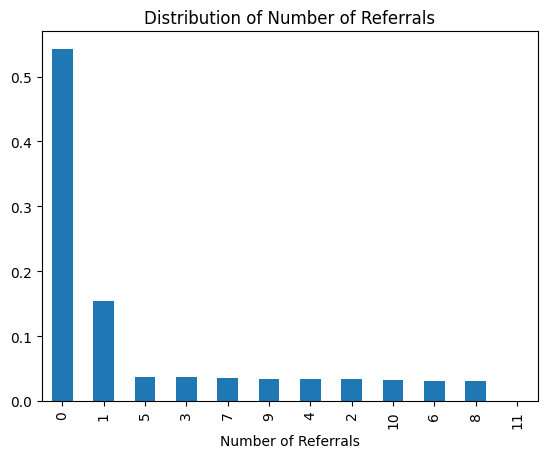

In [29]:
df['Number of Referrals'].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribution of Number of Referrals')

In [30]:
# Distribution of Tenure in Months
# Tenure in Months = How long the customer has been with the company in months
df['Tenure in Months'].describe()

count    7043.000000
mean       32.386767
std        24.542061
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure in Months, dtype: float64

- Important rule `Low Tenure = High churn risk`

Text(0.5, 1.0, 'Distribution of Tenure in Months')

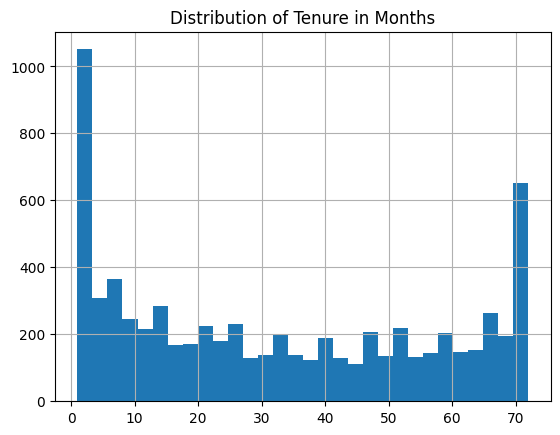

In [31]:
# Distribution of Tenure in Months
df['Tenure in Months'].hist(bins=30)
plt.title('Distribution of Tenure in Months')

In [32]:
# Distribution of Offer
offer = (df['Offer'].value_counts(normalize=True)*100).reset_index()
offer.columns = ['Offer', 'Percentage']
px.bar(offer, x='Offer', y='Percentage', title='Distribution of Offer')


In [33]:
df["Monthly Charge"].describe()


count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charge, dtype: float64

<Axes: >

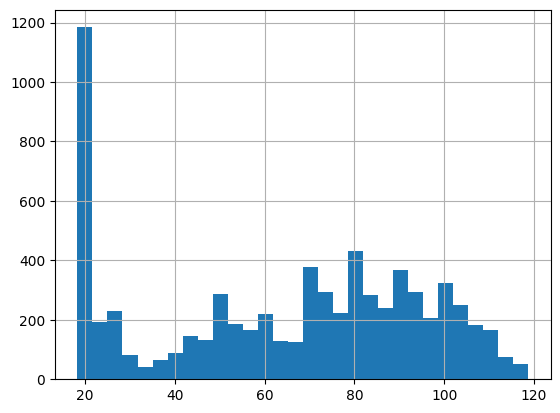

In [34]:
df["Monthly Charge"].hist(bins=30)

In [35]:
# Distribution of Contract
# Contract = The type of contract the customer has with the company (e.g., month-to-month, one year, two year)
contract = (df["Contract"].value_counts(normalize=True)*100).reset_index()
contract.columns = ['Contract', 'Percentage']
px.bar(contract, x='Contract', y='Percentage', title='Distribution of Contract')

In [36]:
df["Internet Service"].value_counts(normalize=True).reset_index()

,Internet Service,proportion
0,Yes,0.783331
1,No,0.216669


In [37]:
df['Avg Monthly GB Download'].describe()

count    7043.000000
mean       20.515405
std        20.418940
min         0.000000
25%         3.000000
50%        17.000000
75%        27.000000
max        85.000000
Name: Avg Monthly GB Download, dtype: float64

<Axes: >

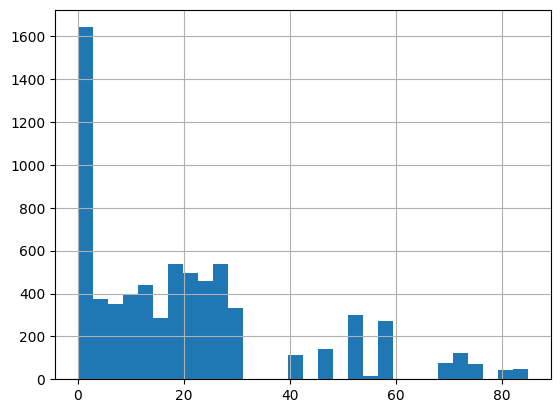

In [38]:
df['Avg Monthly GB Download'].hist(bins=30)

In [39]:
# Distribution of Payment Method
# Payment Method = The method the customer uses to pay their bill (e.g., electronic check, mailed check, bank transfer, credit card)
df['Payment Method'].value_counts(normalize=True).reset_index()

,Payment Method,proportion
0,Bank Withdrawal,0.555019
1,Credit Card,0.390317
2,Mailed Check,0.054664


In [40]:
# Distribution of Satisfaction Score
# Satisfaction Score = A score from 1 to 5 indicating the customer's satisfaction with the service, where 1 is very dissatisfied and 5 is very satisfied
df['Satisfaction Score'].unique()

array([3, 2, 1, 4, 5])

In [41]:
# Distribution of Satisfaction Score
# Satisfaction Score = A score from 1 to 5 indicating the customer's satisfaction with the service, where 1 is very dissatisfied and 5 is very satisfied
df['Satisfaction Score'].value_counts(normalize=True).reset_index()

,Satisfaction Score,proportion
0,3,0.378390
1,4,0.254011
2,5,0.163141
3,1,0.130910
4,2,0.073548


In [42]:
df['Customer Status'].unique()  

array(['Churned', 'Stayed', 'Joined'], dtype=object)

# Bivariate Analysis

In [43]:
# Churn by Contract Type
# Churn  = The percentage of customers who have churned (i.e., left the company) within each contract type
pd.crosstab(df["Contract"], df["Churn Label"], normalize="index").round(2)*100

Churn Label,No,Yes
Contract,,
Month-to-Month,54.0,46.0
One Year,89.0,11.0
Two Year,97.0,3.0


In [44]:
df.groupby("Churn Label")["Tenure in Months"].mean().reset_index()

,Churn Label,Tenure in Months
0,No,37.591225
1,Yes,17.979133


<Axes: xlabel='Churn Label', ylabel='Tenure in Months'>

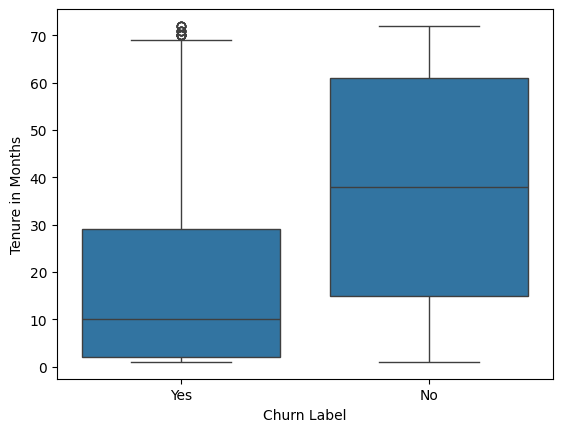

In [45]:
# Churn by Tenure
sns.boxplot(x="Churn Label", y="Tenure in Months", data=df)

<Axes: xlabel='Churn Label', ylabel='Monthly Charge'>

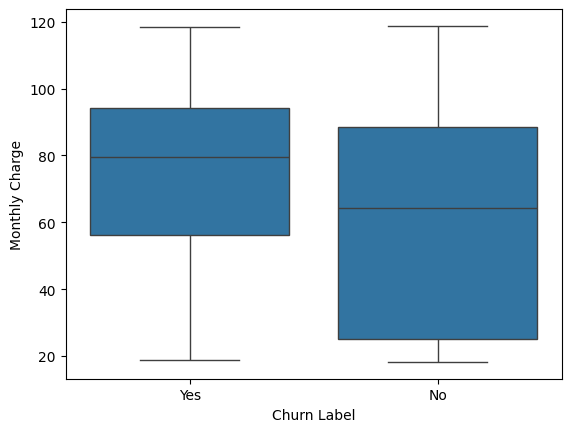

In [46]:
# Churn by Monthly Charge
sns.boxplot(x="Churn Label", y="Monthly Charge", data=df)

In [47]:
# Churn by Payment Method
pd.crosstab(df["Payment Method"], df["Churn Label"], normalize="index").round(2)*100

Churn Label,No,Yes
Payment Method,,
Bank Withdrawal,66.0,34.0
Credit Card,86.0,14.0
Mailed Check,63.0,37.0


In [48]:
# Churn by Age
df.groupby("Churn Label")["Age"].mean().reset_index()

,Churn Label,Age
0,No,45.344414
1,Yes,49.735688


In [49]:
# Churn by Married
pd.crosstab(df["Married"], df["Churn Label"], normalize="index").round(2)*100

Churn Label,No,Yes
Married,,
No,67.0,33.0
Yes,80.0,20.0


In [50]:
pd.crosstab(df["Gender"], df["Churn Label"], normalize="index").round(2)*100

Churn Label,No,Yes
Gender,,
Female,73.0,27.0
Male,74.0,26.0


In [51]:
pd.crosstab(df["Referred a Friend"], df["Churn Label"], normalize="index").round(2)*100

Churn Label,No,Yes
Referred a Friend,,
No,67.0,33.0
Yes,81.0,19.0


In [52]:
pd.crosstab(df['Multiple Lines'], df['Churn Label'], normalize='index').round(2)*100

Churn Label,No,Yes
Multiple Lines,,
No,75.0,25.0
Yes,71.0,29.0


In [53]:
pd.crosstab(df['Offer'], df['Churn Label'], normalize='index').round(2)*100

Churn Label,No,Yes
Offer,,
No,73.0,27.0
Offer A,93.0,7.0
Offer B,88.0,12.0
Offer C,77.0,23.0
Offer D,73.0,27.0
Offer E,47.0,53.0


In [54]:
df['City'].nunique()

1106

# Feature Engineering

In [4]:
df.head(1)

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.0,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data


In [5]:
# Create Tenure Buckets
bins = [0, 6, 12, 24, 100]
labels = ['0-6', '6-12', '12-24', '24+']

df['Tenure_Bucket'] = pd.cut(
    df['Tenure in Months'],
    bins=bins,
    labels=labels,
    right=False
)

df[['Tenure in Months','Tenure_Bucket']].head()

,Tenure in Months,Tenure_Bucket
0,1,0-6
1,8,6-12
2,18,12-24
3,25,24+
4,37,24+


In [6]:
# Create CLTV Buckets
df['Value_Segment'] = pd.qcut(
    df['CLTV'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df[['CLTV','Value_Segment']].head()

,CLTV,Value_Segment
0,5433,High
1,5302,High
2,3179,Low
3,5337,High
4,2793,Low


In [7]:
# Create Revenue per Month
df['Revenue_per_Month'] = df['Total Revenue'] / df['Tenure in Months']

# Processing infinite and NaN values in Revenue_per_Month
df['Revenue_per_Month'] = df['Revenue_per_Month'].replace([float('inf')], 0)
df['Revenue_per_Month'] = df['Revenue_per_Month'].fillna(0)

In [8]:
# Calculate Revenue Deviation
df['Revenue_Deviation'] = df['Revenue_per_Month'] / df['Monthly Charge']
df[['Total Revenue', 'CLTV', 'Monthly Charge', 'Revenue_per_Month','Revenue_Deviation']].head()

,Total Revenue,CLTV,Monthly Charge,Revenue_per_Month,Revenue_Deviation
0,59.65,5433,39.65,59.650000,1.504414
1,1024.10,5302,80.65,128.012500,1.587260
2,1910.88,3179,95.45,106.160000,1.112205
3,2995.07,5337,98.50,119.802800,1.216272
4,3102.36,2793,76.50,83.847568,1.096047


In [13]:
df = df.drop(['Under 30','Senior Citizen','Quarter','Country','State','City','Zip Code','Churn Reason','Churn Score','CLTV','Customer Status'], axis=1)

In [15]:
df = df.drop(['Customer ID','Churn Category'], axis=1)

# Model Building

In [ ]:
# Prepare data for modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

In [40]:
# Separate Features & Target
X = df.drop('Churn Label', axis=1)
y = df['Churn Label'].map({'Yes': 1, 'No': 0})

In [ ]:
# Detecting "false digital" columns containing text
def get_true_numeric_cols(df):
    numeric_candidates = df.select_dtypes(exclude=['object']).columns.tolist()
    true_numeric = []
    for col in numeric_candidates:
        try:
            pd.to_numeric(df[col], errors='raise')
            true_numeric.append(col)
        except (ValueError, TypeError):
            pass
    return true_numeric


for col in X.select_dtypes(exclude=['object']).columns:
    if X[col].astype(str).str.contains(r'[^0-9.\-]|^\-', regex=True).any():
        X[col] = X[col].astype(str)


categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['Gender', 'Married', 'Dependents', 'Longitude', 'Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Tenure_Bucket', 'Value_Segment']
Numeric columns: ['Age', 'Number of Dependents', 'Latitude', 'Population', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Revenue_per_Month', 'Revenue_Deviation']


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# Full Modeling Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Predictions & Evaluation
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1035
           1       0.91      0.93      0.92       374

    accuracy                           0.96      1409
   macro avg       0.94      0.95      0.94      1409
weighted avg       0.96      0.96      0.96      1409

AUC: 0.9919424423260741


In [ ]:
# Overfitting Check
train_acc = pipeline.score(X_train, y_train)
test_acc  = pipeline.score(X_test, y_test)

y_train_pred  = pipeline.predict(X_train)
y_train_proba = pipeline.predict_proba(X_train)[:, 1]

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc  = roc_auc_score(y_test,  y_proba)

print("=" * 40)
print(f"{'Metric':<20} {'Train':>8} {'Test':>8} {'Gap':>8}")
print("=" * 40)
print(f"{'Accuracy':<20} {train_acc:>8.4f} {test_acc:>8.4f} {train_acc - test_acc:>8.4f}")
print(f"{'AUC-ROC':<20} {train_auc:>8.4f} {test_auc:>8.4f} {train_auc - test_auc:>8.4f}")
print("=" * 40)


Metric                  Train     Test      Gap
Accuracy               0.9720   0.9560   0.0160
AUC-ROC                0.9977   0.9919   0.0058


In [49]:
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')

print(f"\nCross-Validation AUC (5-Fold):")
print(f"  Scores : {np.round(cv_scores, 4)}")
print(f"  Mean   : {cv_scores.mean():.4f}")
print(f"  Std    : {cv_scores.std():.4f}")


Cross-Validation AUC (5-Fold):
  Scores : [0.9932 0.9911 0.9931 0.9916 0.9909]
  Mean   : 0.9920
  Std    : 0.0010


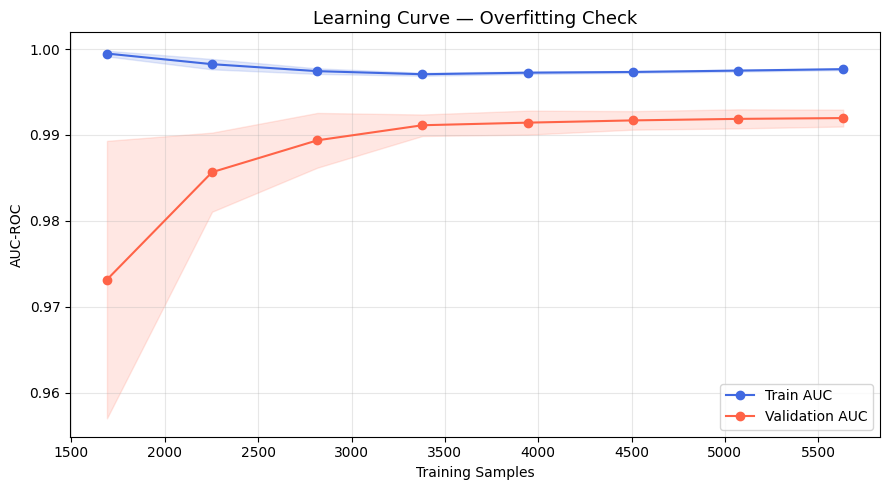

In [50]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X, y,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Train AUC')
plt.plot(train_sizes, val_mean,   'o-', color='tomato',    label='Validation AUC')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
plt.fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.15, color='tomato')
plt.title('Learning Curve — Overfitting Check', fontsize=13)
plt.xlabel('Training Samples')
plt.ylabel('AUC-ROC')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



#  Feature Importance

In [55]:
import shap
from matplotlib.gridspec import GridSpec


ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
all_feature_names = ohe_feature_names + list(numeric_cols)

coefficients = pipeline.named_steps['model'].coef_[0]
importance_df = pd.DataFrame({
    'Feature'    : all_feature_names,
    'Coefficient': coefficients,
    'Abs_Coef'   : np.abs(coefficients)
}).sort_values('Abs_Coef', ascending=False)

print("=" * 55)
print("       TOP 10 FEATURES — Logistic Regression")
print("=" * 55)
print(importance_df[['Feature', 'Coefficient']].head(10).to_string(index=False))

       TOP 10 FEATURES — Logistic Regression
              Feature  Coefficient
   Satisfaction Score    -6.899853
  Online Security_Yes    -2.647084
       Dependents_Yes    -1.873819
  Number of Referrals    -1.832767
Longitude_-117.202937     1.708415
Longitude_-117.277533     1.693261
Longitude_-117.209774     1.647189
    Contract_Two Year    -1.521150
Longitude_-117.667677     1.491883
Longitude_-117.152162     1.477380


In [56]:
# SHAP Values
X_train_transformed = pipeline.named_steps['preprocessor'].transform(X_train)
X_test_transformed  = pipeline.named_steps['preprocessor'].transform(X_test)

explainer   = shap.LinearExplainer(
    pipeline.named_steps['model'],
    X_train_transformed,
    feature_names=all_feature_names
)
shap_values = explainer(X_test_transformed)

shap_df = pd.DataFrame(np.abs(shap_values.values), columns=all_feature_names)
top5     = shap_df.mean().sort_values(ascending=False).head(5)
top5_idx = [all_feature_names.index(f) for f in top5.index]

print("=" * 55)
print("        🔥 TOP 5 CHURN DRIVERS (SHAP)")
print("=" * 55)
for i, (feat, val) in enumerate(top5.items(), 1):
    print(f"  {i}. {feat:<35} {val:.4f}")
print("=" * 55)

        🔥 TOP 5 CHURN DRIVERS (SHAP)
  1. Satisfaction Score                  5.1570
  2. Number of Referrals                 1.4180
  3. Online Security_Yes                 1.0699
  4. Dependents_Yes                      0.6737
  5. Contract_Two Year                   0.6048


In [57]:
BG      = '#0f1117'
PANEL   = '#1a1d27'
WHITE   = '#ffffff'
GRAY    = '#888888'
COLORS  = ['#00d4ff','#ff6b6b','#ffd166','#06d6a0','#a855f7']

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=WHITE, fontsize=13, fontweight='bold', pad=14)
    ax.tick_params(colors=GRAY, labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)

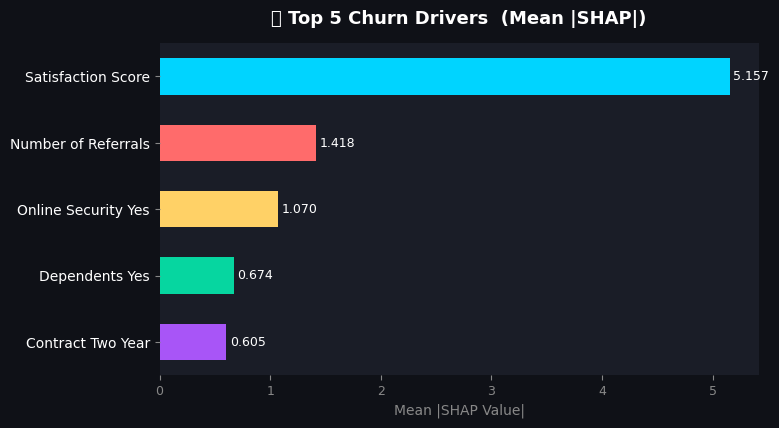

In [58]:
# ── Figure 1: Top 5 SHAP Bar ──────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 4.5))
fig1.patch.set_facecolor(BG)
style_ax(ax1, '🔥 Top 5 Churn Drivers  (Mean |SHAP|)')

labels = [f.replace('_', ' ') for f in top5.index[::-1]]
ax1.barh(range(5), top5.values[::-1], color=COLORS[::-1],
         edgecolor='none', height=0.55)
ax1.set_yticks(range(5))
ax1.set_yticklabels(labels, color=WHITE, fontsize=10)
ax1.set_xlabel('Mean |SHAP Value|', color=GRAY, fontsize=10)
ax1.xaxis.label.set_color(GRAY)
ax1.tick_params(axis='x', colors=GRAY)

for i, v in enumerate(top5.values[::-1]):
    ax1.text(v + 0.03, i, f'{v:.3f}', va='center', color=WHITE, fontsize=9)

plt.tight_layout(pad=1.5)
plt.savefig('plot1_top5_shap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

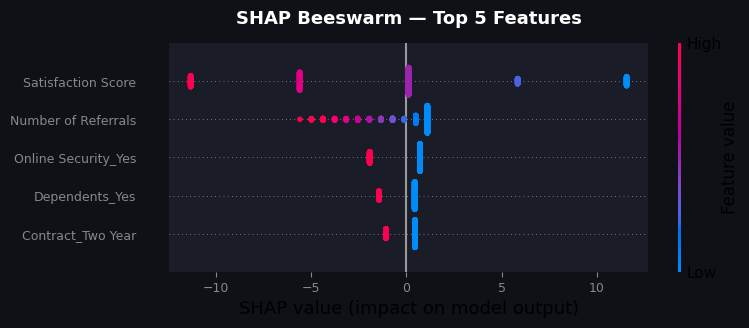

In [59]:
# ── Figure 2: SHAP Beeswarm ───────────────────────────────
shap_top5 = shap_values[:, top5_idx]

fig2, ax2 = plt.subplots(figsize=(9, 4.5))
fig2.patch.set_facecolor(BG)
ax2.set_facecolor(PANEL)
plt.sca(ax2)

shap.plots.beeswarm(shap_top5, max_display=5, show=False, color_bar=True)

ax2.set_facecolor(PANEL)
ax2.set_title('SHAP Beeswarm — Top 5 Features', color=WHITE,
              fontsize=13, fontweight='bold', pad=14)
ax2.tick_params(colors=GRAY, labelsize=9)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout(pad=1.5)
plt.savefig('plot2_beeswarm.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


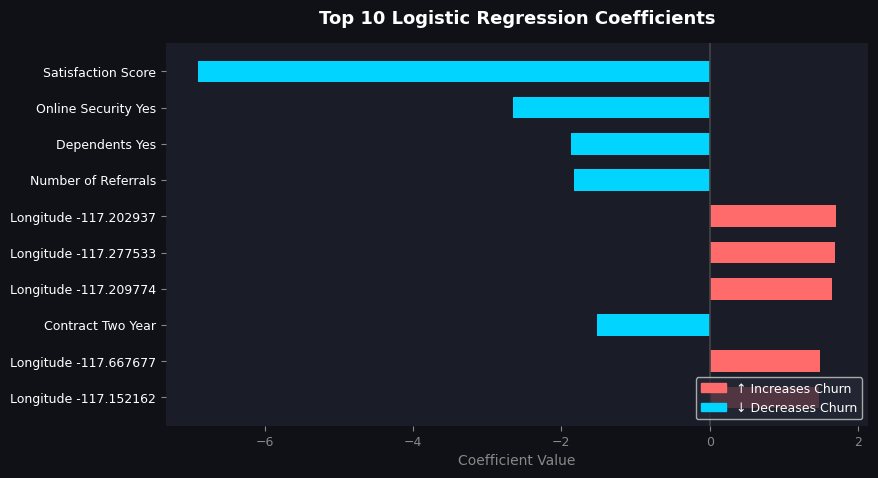

In [60]:
# ── Figure 3: Top 10 LR Coefficients ─────────────────────
top10 = importance_df.head(10)

fig3, ax3 = plt.subplots(figsize=(9, 5))
fig3.patch.set_facecolor(BG)
style_ax(ax3, 'Top 10 Logistic Regression Coefficients')

bar_colors = ['#ff6b6b' if c > 0 else '#00d4ff' for c in top10['Coefficient'].values[::-1]]
ax3.barh(range(10), top10['Coefficient'].values[::-1],
         color=bar_colors, edgecolor='none', height=0.6)

labels10 = [f.replace('_', ' ')[:30] for f in top10['Feature'].values[::-1]]
ax3.set_yticks(range(10))
ax3.set_yticklabels(labels10, color=WHITE, fontsize=9)
ax3.set_xlabel('Coefficient Value', color=GRAY, fontsize=10)
ax3.axvline(0, color='#444', linewidth=1.2)
ax3.tick_params(axis='x', colors=GRAY)

patch1 = mpatches.Patch(color='#ff6b6b', label='↑ Increases Churn')
patch2 = mpatches.Patch(color='#00d4ff', label='↓ Decreases Churn')
ax3.legend(handles=[patch1, patch2], facecolor='#252836',
           labelcolor=WHITE, fontsize=9, framealpha=0.8, loc='lower right')

plt.tight_layout(pad=1.5)
plt.savefig('plot3_coefficients.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


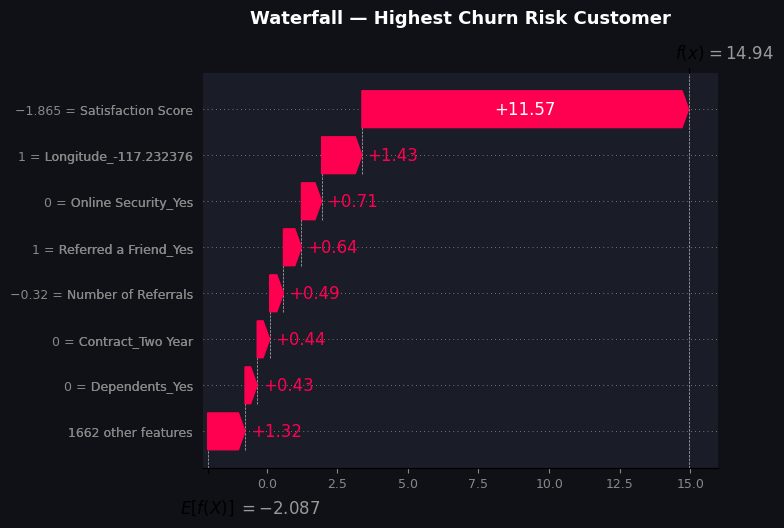


✅ تم حفظ 4 صور منفصلة:
   plot1_top5_shap.png
   plot2_beeswarm.png
   plot3_coefficients.png
   plot4_waterfall.png


In [61]:
# ── Figure 4: Waterfall For the highest risk client─────────────────
highest_idx = int(np.argmax(y_proba))

fig4, ax4 = plt.subplots(figsize=(9, 5))
fig4.patch.set_facecolor(BG)
ax4.set_facecolor(PANEL)
plt.sca(ax4)

shap.plots.waterfall(shap_values[highest_idx], max_display=8, show=False)

ax4.set_facecolor(PANEL)
ax4.set_title('Waterfall — Highest Churn Risk Customer', color=WHITE,
              fontsize=13, fontweight='bold', pad=14)
ax4.tick_params(colors=GRAY, labelsize=9)
for spine in ax4.spines.values():
    spine.set_visible(False)

plt.tight_layout(pad=1.5)
plt.savefig('plot4_waterfall.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print("\n✅ تم حفظ 4 صور منفصلة:")
print("   plot1_top5_shap.png")
print("   plot2_beeswarm.png")
print("   plot3_coefficients.png")
print("   plot4_waterfall.png")

# Model Deployment

In [62]:
import joblib
import json

# Save model
joblib.dump(pipeline, 'churn_model.pkl')

# Save feature config for the app
feature_config = {
    'categorical_cols': categorical_cols,
    'numeric_cols'    : list(numeric_cols),
    'all_columns'     : list(X.columns)
}
with open('feature_config.json', 'w') as f:
    json.dump(feature_config, f)

print("✅ churn_model.pkl      — saved")
print("✅ feature_config.json  — saved")

✅ churn_model.pkl      — saved
✅ feature_config.json  — saved


In [12]:
import streamlit as st
import joblib, json, shap

# ── Config ────────────────────────────────────────────────
st.set_page_config(
    page_title="Churn Predictor",
    page_icon="📡",
    layout="centered"
)

# ── Load Model ────────────────────────────────────────────
@st.cache_resource
def load_model():
    model = joblib.load('churn_model.pkl')
    with open('feature_config.json') as f:
        config = json.load(f)
    return model, config

pipeline, config = load_model()
cat_cols = config['categorical_cols']
num_cols = config['numeric_cols']

C:\Users\Ctrl-Halim\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-03 05:28:25.461 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 05:28:25.462 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [13]:
# ── Styling ───────────────────────────────────────────────
st.markdown("""
<style>
    .main { background-color: #0f1117; }
    .stApp { background-color: #0f1117; color: white; }
    .metric-box {
        background: #1a1d27;
        border-radius: 12px;
        padding: 20px;
        text-align: center;
        border: 1px solid #2a2d3a;
    }
    .risk-high { color: #ff6b6b; font-size: 2.5rem; font-weight: bold; }
    .risk-low  { color: #06d6a0; font-size: 2.5rem; font-weight: bold; }
    div[data-testid="stSidebar"] { background-color: #1a1d27; }
</style>
""", unsafe_allow_html=True)

2026-03-03 05:28:28.964 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 05:28:29.308 
  command:

    streamlit run C:\Users\Ctrl-Halim\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-03 05:28:29.309 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 05:28:29.309 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [25]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib, json, shap

st.set_page_config(page_title="Churn Predictor", page_icon="📡", layout="centered")

@st.cache_resource
def load_model():
    model = joblib.load('churn_model.pkl')
    with open('feature_config.json') as f:
        config = json.load(f)
    return model, config

pipeline, config = load_model()
cat_cols = config['categorical_cols']
num_cols = config['numeric_cols']

st.markdown("# 📡 Customer Churn Predictor")
st.markdown("Enter customer data and the model will predict the likelihood of churn.")
st.divider()

st.sidebar.markdown("## 👤 Customer Information")

def user_input():
    inputs = {}
    st.sidebar.markdown("### 📊 Numerical data")
    numeric_defaults = {
        "Tenure Months"      : (1,   72,  12),
        "Monthly Charges"    : (10., 120., 65.),
        "Total Charges"      : (10., 9000., 1500.),
        "Number of Referrals": (0,   10,   2),
        "Satisfaction Score" : (1,   5,    3),
        "CLTV"               : (1000, 8000, 3500),
    }
    for col in num_cols:
        if col in numeric_defaults:
            lo, hi, default = numeric_defaults[col]
            if isinstance(lo, float):
                inputs[col] = st.sidebar.slider(col, float(lo), float(hi), float(default))
            else:
                inputs[col] = st.sidebar.slider(col, int(lo), int(hi), int(default))
        else:
            inputs[col] = st.sidebar.number_input(col, value=0.0)

    st.sidebar.markdown("### 🏷️ Categorical data")
    cat_options = {
        "Gender"               : ["Male", "Female"],
        "Senior Citizen"       : ["No", "Yes"],
        "Partner"              : ["No", "Yes"],
        "Dependents"           : ["No", "Yes"],
        "Phone Service"        : ["No", "Yes"],
        "Multiple Lines"       : ["No", "Yes", "No phone service"],
        "Internet Service"     : ["DSL", "Fiber Optic", "No"],
        "Online Security"      : ["No", "Yes", "No internet service"],
        "Online Backup"        : ["No", "Yes", "No internet service"],
        "Device Protection Plan": ["No", "Yes", "No internet service"],
        "Premium Tech Support" : ["No", "Yes", "No internet service"],
        "Streaming TV"         : ["No", "Yes", "No internet service"],
        "Streaming Movies"     : ["No", "Yes", "No internet service"],
        "Streaming Music"      : ["No", "Yes", "No internet service"],
        "Unlimited Data"       : ["No", "Yes"],
        "Contract"             : ["Month-to-Month", "One Year", "Two Year"],
        "Paperless Billing"    : ["No", "Yes"],
        "Payment Method"       : ["Bank Withdrawal", "Credit Card", "Mailed Check"],
        "Referred a Friend"    : ["No", "Yes"],
        "Offer"                : ["None", "Offer A", "Offer B", "Offer C", "Offer D", "Offer E"],
    }
    for col in cat_cols:
        options = cat_options.get(col, ["No", "Yes"])
        inputs[col] = st.sidebar.selectbox(col, options)

    return pd.DataFrame([inputs])

input_df = user_input()

if st.sidebar.button("🔮 Predict Churn", use_container_width=True, type="primary"):
    proba    = pipeline.predict_proba(input_df)[0][1]
    label    = pipeline.predict(input_df)[0]
    risk_pct = proba * 100

    st.markdown("## 📊 Prediction Results")
    col1, col2, col3 = st.columns(3)
    with col1:
        st.metric("Churn Probability", f"{risk_pct:.1f}%")
    with col2:
        st.metric("Prediction", "🔴 Will Churn" if label == 1 else "🟢 Will Stay")
    with col3:
        if risk_pct >= 70:
            level = "⚠️ Very High"
        elif risk_pct >= 40:
            level = "🟡 Medium"
        else:
            level = "✅ Low"
        st.metric("Risk Level", level)

    st.markdown(f"**Churn Probability: {risk_pct:.1f}%**")
    st.progress(proba)

    st.divider()
    st.markdown("## 🔍 Reasons for Prediction (SHAP)")
    try:
        preprocessor = pipeline.named_steps["preprocessor"]
        model        = pipeline.named_steps["model"]
        ohe          = preprocessor.named_transformers_["cat"]
        ohe_names    = ohe.get_feature_names_out(cat_cols).tolist()
        all_names    = ohe_names + list(num_cols)
        X_transformed = preprocessor.transform(input_df)
        explainer     = shap.LinearExplainer(model, X_transformed, feature_names=all_names)
        shap_vals     = explainer(X_transformed)
        shap_series   = pd.Series(shap_vals.values[0], index=all_names)
        st.markdown("#### 🔴 Factors that increase Churn Risk")
        for feat, val in shap_series.nlargest(5).items():
            st.markdown(f"- **{feat}** → `+{val:.3f}`")
        st.markdown("#### 🟢 Factors that decrease Churn Risk")
        for feat, val in shap_series.nsmallest(3).items():
            st.markdown(f"- **{feat}** → `{val:.3f}`")
    except Exception as e:
        st.info(f"SHAP Not available: {e}")

    st.divider()
    st.markdown("## 💡 Recommendation")
    if risk_pct >= 70:
        st.error("🚨 Very high risk! Immediate contact and retention offer recommended.")
    elif risk_pct >= 40:
        st.warning("⚠️ Medium risk. Monitor this customer and consider upgrade offers.")
    else:
        st.success("✅ The customer is stable. Continue providing good service.")
else:
    st.info("👈 Enter customer data in the sidebar and click **Predict**")
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("✅ app.py Save Successful")

✅ app.py Save Successful


In [26]:
import os
files = ['app.py', 'churn_model.pkl', 'feature_config.json']
for f in files:
    status = "✅" if os.path.exists(f) else "❌ مش موجود"
    print(f"{status}  {f}")

✅  app.py
✅  churn_model.pkl
✅  feature_config.json


In [1]:
import os
print(os.getcwd())

m:\Instant Diploma\Coding\End_to_End_project
